# E2: a fresh NL→FOL faithfulness test set (partial, stopped by budget): the `data.py` assembly step

This notebook runs the artifact's **`data.py`** on a small sample. `data.py` builds `full_data_out.json` for
**E2**, a fresh confirmation set for NL→FOL *faithfulness* metrics. E2 is disjoint from the earlier dataset E and is labelled by E's
byte-identical, frozen labeller.

What `data.py` does:
1. Loads the assembled E2 rows (`work/assembled_E2.json`, output of `src_e2/assemble_e2.py`). These are the real system candidates,
   the gold-as-system rows and the pre-registered sentences.
2. **Re-checks every row against its original source.** Sources are the MALLS-v0.1 train/test gold FOL, the ProverQA dev `nl2fol` / `conclusion_fol`,
   and the raw LLM generation log. Each row gets a `metadata_source_verified` flag and a `metadata_source_file`.
   - `e2_candidates`: raw output == the *last* generation record for (sentence, slot, prompt variant), `candidate_fol == normalise(raw)`,
     and the text is found in a source.
   - `e2_gold_as_system`: candidate == the source's gold formula.
   - `e2_sentences`: text + gold == the source record.
   - `e2_panel_drift`: one row per replayed LLM-panel item, with E's stored votes next to today's replayed votes.
3. Checks the schema (only `input`, `output`, `metadata_*` keys) and writes the `full` / `mini` / `preview` JSON files.

**Artifact state.** E2 is PARTIAL. The run's OpenRouter budget ran out, so only a 30-sentence pilot (300 real candidates) was generated
and labelled. 520 sentences are `PENDING_GENERATION_BUDGET_STOP`, no panel votes exist for E2 candidates, and the track-H panel replay was
cut off. **No metric is computed here.** This step only assembles and verifies the data.

**Demo data.** `mini_demo_data.json` holds a subset of *every input file* `data.py` reads:
5 pilot sentences with all 50 candidates, 5 gold-as-system rows, 20 sentences, 12 gate items + 8 track-H pairs, and the source records,
generation records and panel-cache votes those rows need. `build_mini_demo_data.py` in the repo shows how it was cut.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# matplotlib, pandas — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
The original `data.py` import block, plus `re` / `unicodedata` (used by the copied `normalise` module) and matplotlib/pandas for the
final summary. In the original, `normalise` is imported from `src/normalise.py`, and `calib_votes` / `trackh_votes` from
`src_e2/drift_report.py`. Those helpers are copied verbatim into cells below so the notebook is self-contained.

In [2]:
from __future__ import annotations

import json
import sys
from collections import Counter
from pathlib import Path

from loguru import logger

# used by the copied src/normalise.py
import re
import unicodedata

# notebook-only: summary table and plots
import pandas as pd
import matplotlib.pyplot as plt

## Load the demo data
Tries the GitHub raw URL first (Colab), then falls back to a local `mini_demo_data.json`.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/main/round-4/dataset-4/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print({k: (len(v) if isinstance(v, (list, dict)) else v) for k, v in data.items()})

{'about': 'Input bundle for the E2 demo notebook: a subset of every file data.py reads (see build_mini_demo_data.py).', 'assembled_E2': 2, 'controls_E2': 2, 'sources': 5, 'generations': 52, 'panel_prompt_sha1': '0b5ffbb951ec3d5489bb64812387b064354cc905', 'calibration_items': 12, 'E_panel_cache': 81, 'E2_panel_cache': 27, 'E_trackh_panel_rows': 8, 'E2_trackh_panel_rows': 8}


## Configuration
`data.py` has no training loop. Its only size parameters are how many rows of each group it processes, plus the mini/preview sizes.
The original always processes **every** row: 300 candidates, 30 gold-as-system rows, 550 sentences and 77 + 96 drift items.
The demo bundle holds 50 / 5 / 20 / 12 + 8 of these, and `None` means "all rows in the bundle".

In [5]:
MAX_CANDIDATES = None      # rows of e2_candidates to process      (original: all 300; bundle: 50)
MAX_GOLD = None            # rows of e2_gold_as_system              (original: all 30;  bundle: 5)
MAX_SENTENCES = None       # rows of e2_sentences                   (original: all 550; bundle: 20)
MAX_DRIFT_CALIB = None     # synthetic gate items in e2_panel_drift (original: all 77;  bundle: 12)
MAX_DRIFT_TRACKH = None    # track-H pairs in e2_panel_drift        (original: all 96;  bundle: 8)
MINI_EXAMPLES = 3          # rows per group in mini_data_out.json   (original: 3)
PREVIEW_TRUNC_CHARS = 200  # string truncation in preview_data_out.json (original: 200)
LIMIT = 100 * 1000 * 1000  # max full_data_out.json size in bytes   (original: 100 MB)
OUT_DIR = Path("demo_output")  # original wrote next to data.py

## Surface normaliser (verbatim copy of `src/normalise.py`)
E's frozen LLM-output normaliser. It does no semantic repair, only surface syntax mapping: it strips code fences and the `FOL:` prefix, keeps the first
formula line, unwraps LaTeX, maps ASCII connectives to Unicode, and folds diacritics. `data.py` uses it to check that each stored
`candidate_fol` is exactly `normalise(raw_output)`.

In [6]:
LATEX = [
    (r"\\text\{([^{}]*)\}", r"\1"), (r"\\mathrm\{([^{}]*)\}", r"\1"), (r"\\operatorname\{([^{}]*)\}", r"\1"),
    (r"\\forall\s*", "∀"), (r"\\exists\s*", "∃"), (r"\\land\b|\\wedge\b", "∧"), (r"\\lor\b|\\vee\b", "∨"),
    (r"\\neg\b|\\lnot\b", "¬"), (r"\\leftrightarrow\b|\\iff\b|\\Leftrightarrow\b", "↔"),
    (r"\\rightarrow\b|\\to\b|\\Rightarrow\b|\\implies\b", "→"), (r"\\oplus\b", "⊕"),
    (r"\\\(|\\\)|\\\[|\\\]|\$", ""), (r"\\[,;!: ]", " "),
]
WORDOPS = [
    (r"\bforall\s+([a-z][a-z0-9]*)\s*[.:]?", r"∀\1 "), (r"\ball\s+([a-z])\s*\.", r"∀\1 "),
    (r"\bexists\s+([a-z][a-z0-9]*)\s*[.:]?", r"∃\1 "), (r"\bexist\s+([a-z])\s*\.", r"∃\1 "),
    (r"<->|<=>|⟷|⇔|≡", "↔"), (r"->|=>|⟶|⇒|⊃", "→"), (r"&&|&", "∧"), (r"\|\||\|", "∨"),
    (r"\bxor\b|⊻", "⊕"), (r"\bnot\s+", "¬"), (r"[~!]|¬", "¬"), (r"\band\b", "∧"), (r"\bor\b", "∨"),
]


def normalise(raw: str | None) -> tuple[str, list[str]]:
    applied: list[str] = []
    if raw is None:
        return "", ["none"]
    s = raw.strip()
    if "```" in s:
        m = re.search(r"```(?:[a-zA-Z]*)\n?(.*?)```", s, re.S)
        if m:
            s = m.group(1).strip()
            applied.append("code_fence")
    m = re.search(r"FOL\s*[:：]\s*(.+)", s)
    if m:
        s = m.group(1)
        applied.append("fol_prefix")
    lines = [ln.strip() for ln in s.splitlines() if ln.strip()]
    if len(lines) > 1:
        applied.append("first_line")
    s = lines[0] if lines else ""
    if "\\" in s or "$" in s:
        for a, b in LATEX:
            s = re.sub(a, b, s)
        applied.append("latex")
    s2 = s
    for a, b in WORDOPS:
        s2 = re.sub(a, b, s2)
    if s2 != s:
        applied.append("ascii_ops")
    s = s2.strip().strip("`").strip()
    s = re.sub(r"\s+", " ", s).rstrip(".")
    folded = "".join(_fold(ch) for ch in s)
    if folded != s:
        applied.append("ascii_fold")
        s = folded
    return s, applied


def _fold(ch: str) -> str:
    """Diacritic folding of non-ASCII LETTERS only (Sūduva -> Suduva); logic symbols are untouched."""
    if ch.isascii() or not unicodedata.category(ch).startswith("L"):
        return ch
    base = "".join(c for c in unicodedata.normalize("NFKD", ch) if not unicodedata.combining(c))
    return base if base.isascii() and base else "_"

## Panel-vote helpers (copied from `src_e2/drift_report.py`)
The LLM panel has three judges (P1 = claude-haiku-4.5, P3 = glm-4.6, R1 = kimi-k2). `calib_votes` reads each judge's faithful/unfaithful verdict
for the 77 synthetic gate items out of a panel cache. `trackh_votes` does the same for the 96 track-H real-error pairs (original vs corrected
formula). **One change:** the original `calib_votes` reads a `.jsonl` file path, while here it takes the already-loaded list of cache records.
`PROMPT_SHA1` is the hash of the frozen panel prompt from `src/panel.py`. It is stored in the bundle because `panel.py` needs the API client.

In [7]:
PROMPT_SHA1 = data["panel_prompt_sha1"]  # original: from panel import PROMPT_SHA1
MEM = ["P1", "P3", "R1"]


def calib_votes(cache_records: list) -> dict:  # original: calib_votes(cache_path) iterating open(cache_path)
    out: dict = {}
    for r in cache_records:
        if r.get("parsed") and r["sentence_id"].startswith("calib|") and r["prompt_sha1"] == PROMPT_SHA1 and r["member"] in MEM:
            for cid, v in r["verdicts"].items():
                key = cid if cid != "REF" else "REF|" + r["sentence_id"]
                out.setdefault(key, {})[r["member"]] = bool(v["faithful"])
    return out


def trackh_votes(rows: list) -> dict:
    out = {}
    for r in rows:
        for m, v in r["votes"].items():
            if m in MEM:
                out.setdefault(f"H{r['id']}:orig", {})[m] = bool(v["orig_faithful"])
                out.setdefault(f"H{r['id']}:corr", {})[m] = bool(v["corr_faithful"])
    return out


def majority(v: dict):
    f = sum(v.values())
    u = len(v) - f
    return True if f >= 2 else (False if u >= 2 else None)

## Setup: logging, constants and the source index
These are the `data.py` module-level constants. The logger writes to stdout plus a log file, as in the original.
`source_index()` maps **text → (gold FOL, source file)** over every MALLS record and every ProverQA `nl2fol` unit and conclusion,
keeping the first occurrence. The only change is that records come from `data["sources"]` and not from `temp/datasets/`.
The bundle keeps the original record order, so the first occurrence wins exactly as in the full index.

In [8]:
ROOT = OUT_DIR
ROOT.mkdir(exist_ok=True)
(ROOT / "logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
logger.add(ROOT / "logs" / "data_py.log", rotation="30 MB", level="DEBUG")
FORBIDDEN = {"split", "dataset", "context"}
Q_PREFIX = "Based on the above information, is the following statement true, false, or uncertain? "


def source_index() -> dict:
    """text -> (gold, source_file) for every candidate source record."""
    idx = {}
    for f in ("yuan-yang__MALLS-v0__MALLS-v0.1-train.json", "yuan-yang__MALLS-v0__MALLS-v0.1-test.json"):
        for r in data["sources"][f]:  # original: json.loads((TD / f).read_text())
            idx.setdefault(r["NL"].strip(), (r["FOL"].strip(), f))
    for diff in ("easy", "medium", "hard"):
        f = f"opendatalab__ProverQA__dev_{diff}.json"
        for r in data["sources"][f]:  # original: json.loads((TD / f).read_text())
            for t, fo in r["nl2fol"].items():
                idx.setdefault(t.strip(), (fo.strip(), f))
            q = r["question"][len(Q_PREFIX):] if r["question"].startswith(Q_PREFIX) else r["question"]
            idx.setdefault(q.strip(), (r["conclusion_fol"].strip(), f))
    return idx

## Step 1: load the assembled rows, the source index and the generation log
This is the start of `main()`. `gens` keeps the **last** generation record per (sentence, slot, prompt variant), because retries overwrite
earlier attempts. `vcheck` counts every verification outcome.

In [9]:
asm = data["assembled_E2"]  # original: json.loads((W / "assembled_E2.json").read_text())
g = {x["dataset"]: x["examples"] for x in asm["datasets"]}
idx = source_index()
gens = {}
for r in data["generations"]:  # original: jl(TD / "generations.jsonl")
    if r.get("raw_output") is not None:
        gens[(r["sentence_id"], r["slot"], r["prompt_variant"])] = r
sent_by = {s["metadata_sentence_id"]: s for s in g["e2_sentences"]}
verified = Counter()

def vcheck(tag: str, ok: bool) -> bool:
    verified[f"{tag}_{ok}"] += 1
    return ok

print(f"source index: {len(idx)} texts; generation keys: {len(gens)}; groups: { {k: len(v) for k, v in g.items()} }")

source index: 27 texts; generation keys: 50; groups: {'e2_candidates': 50, 'e2_gold_as_system': 5, 'e2_sentences': 20}


## Step 2: verify the real system candidates (`e2_candidates`)
For each LLM candidate there are three checks:
(a) its text is found in a source,
(b) the stored raw output equals the last generation record,
(c) E's normaliser applied to that raw output reproduces the stored `candidate_fol`.
The `reference_fol` is moved out of `input` into metadata, so a metric that only sees `input` never sees the gold.

In [10]:
cands = []
for r in g["e2_candidates"][:MAX_CANDIDATES]:
    inp = json.loads(r["input"])
    sid = r["metadata_sentence_id"]
    src = idx.get(inp["text"].strip())
    gen = gens.get((sid, r["metadata_slot"], r["metadata_prompt_variant"]))
    ok = bool(src) and gen is not None and gen["raw_output"] == r["metadata_raw_output"] and normalise(gen["raw_output"])[0] == inp["candidate_fol"]
    r = dict(r)
    r["input"] = json.dumps({"text": inp["text"], "candidate_fol": inp["candidate_fol"], "system": inp["system"],
                             "prompt_variant": inp["prompt_variant"]}, ensure_ascii=False)
    r["metadata_reference_fol"] = inp["reference_fol"]
    r["metadata_model"] = r["metadata_generator_model_id"]
    r["metadata_model_returned"] = gen.get("model_returned") if gen else None
    r["metadata_latency_s"] = None  # E's frozen generate.py does not record latency (documented in the card)
    r["metadata_source_verified"] = vcheck("cand", ok)
    r["metadata_source_file"] = src[1] if src else None
    cands.append(r)
print(len(cands), "candidate rows;", dict(verified))

50 candidate rows; {'cand_True': 50}


## Step 3: verify the gold-as-system rows and the sentences
- `e2_gold_as_system`: the dataset's own gold formula is submitted as if it were a system output. Here the candidate must match the source gold exactly.
- `e2_sentences`: the pre-registered sentences, including the 520 `PENDING_GENERATION_BUDGET_STOP` ones. Their text and
  `metadata_original_reference_fol` must match the source record.

In [11]:
golds = []
for r in g["e2_gold_as_system"][:MAX_GOLD]:
    inp = json.loads(r["input"])
    src = idx.get(inp["text"].strip())
    ok = bool(src) and src[0] == inp["candidate_fol"].strip()
    r = dict(r)
    r["input"] = json.dumps({"text": inp["text"], "candidate_fol": inp["candidate_fol"], "system": inp["system"],
                             "prompt_variant": inp["prompt_variant"]}, ensure_ascii=False)
    r["metadata_reference_fol"] = inp["reference_fol"]
    r["metadata_source_verified"] = vcheck("gold", ok)
    r["metadata_source_file"] = src[1] if src else None
    golds.append(r)
sents = []
for r in g["e2_sentences"][:MAX_SENTENCES]:
    inp = json.loads(r["input"])
    src = idx.get(inp["text"].strip())
    ok = bool(src) and src[0] == r["metadata_original_reference_fol"].strip()
    r = dict(r)
    r["metadata_source_verified"] = vcheck("sent", ok)
    r["metadata_source_file"] = src[1] if src else None
    sents.append(r)
print(len(golds), "gold-as-system rows,", len(sents), "sentence rows;", dict(verified))

5 gold-as-system rows, 20 sentence rows; {'cand_True': 50, 'gold_True': 5, 'sent_True': 20}


## Step 4: controls (empty) and the panel-drift rows
Meaning-preserving *controls* (renamed or reordered copies of CORRECT candidates) come from rows whose final label is CORRECT. The budget stop left
0 CORRECT rows, so `controls_E2.json` is empty and the group is omitted.

`drift_rows()` builds one row per replayed panel item. Each row pairs E's **stored** votes with the E2 **replay** votes, which come from a fresh cache and the same frozen prompt.
There are two kinds of item. The *synthetic gate* items are gold perturbations with a known FAITHFUL/UNFAITHFUL label. The *track-H* items are real error pairs
(original vs corrected formula). Replay votes are `None` where the replay was cut off by the budget stop.
The code is the original apart from where the inputs are read from.

In [12]:
ctrl = data["controls_E2"]["rows"]  # original: json.loads((W / "controls_E2.json").read_text())["rows"] if it exists else []
parents = {r["metadata_row_key"] for r in cands}
for r in ctrl:
    r["metadata_source_verified"] = vcheck("ctrl", r["metadata_control_parent_row_key"] in parents and bool(r["metadata_inverse_map_z3_equivalent"]))


def drift_rows() -> list[dict]:
    """One row per replayed drift item with E's stored votes and today's votes (None where the replay was cut off)."""
    items = data["calibration_items"][:MAX_DRIFT_CALIB]   # original: W / "calibration_items.json"
    old_c = calib_votes(data["E_panel_cache"])            # original: E_DIR / "work" / "panel_cache.jsonl"
    new_c = calib_votes(data["E2_panel_cache"])           # original: W / "panel_cache.jsonl"
    rows = []
    for it in items:
        rows.append({"input": json.dumps({"text": it["text"], "candidate_fol": it["variant_fol"], "reference_fol": it["reference_fol"]}, ensure_ascii=False),
                     "output": it["gold"], "metadata_fold": "E2_PANEL_DRIFT", "metadata_subset": "synthetic_gate",
                     "metadata_item": it["calib_id"], "metadata_variant_type": it["variant_type"],
                     "metadata_E_stored_votes": old_c.get(it["calib_id"]), "metadata_E2_replay_votes": new_c.get(it["calib_id"]),
                     "metadata_source_verified": True, "metadata_source_file": "E/work/calibration_items.json"})
    old_rows = data["E_trackh_panel_rows"][:MAX_DRIFT_TRACKH]  # original: E_DIR / "work" / "trackh_panel_rows.json"
    new_h = trackh_votes(data["E2_trackh_panel_rows"])         # original: W / "trackh_panel_rows.json"
    old_h = trackh_votes(old_rows)
    for r in old_rows:
        rows.append({"input": json.dumps({"text": r["text"], "original_fol": r["orig"], "corrected_fol": r["corr"]}, ensure_ascii=False),
                     "output": "ORIGINAL_UNFAITHFUL__CORRECTED_FAITHFUL", "metadata_fold": "E2_PANEL_DRIFT", "metadata_subset": "trackH_real_error_pairs",
                     "metadata_item": r["id"], "metadata_ambiguous_curated": r["ambiguous"],
                     "metadata_E_stored_votes": {"orig": old_h.get(f"H{r['id']}:orig"), "corr": old_h.get(f"H{r['id']}:corr")},
                     "metadata_E2_replay_votes": {"orig": new_h.get(f"H{r['id']}:orig"), "corr": new_h.get(f"H{r['id']}:corr")},
                     "metadata_source_verified": True, "metadata_source_file": "E/work/trackh_panel_rows.json"})
    return rows


drift = drift_rows()
print(len(drift), "panel-drift rows")

20 panel-drift rows


## Step 5: schema check and output files
Every row may only contain `input`, `output` and `metadata_*` keys, and no forbidden key (`split`, `dataset`, `context`). Empty groups are
omitted and listed in the metadata. The script then writes `full_data_out.json`, `mini_data_out.json` (first `MINI_EXAMPLES` rows per group) and
`preview_data_out.json` (strings truncated to `PREVIEW_TRUNC_CHARS`). The notebook writes them to `demo_output/`.

In [13]:
def _trunc(o, n: int = PREVIEW_TRUNC_CHARS):
    """Preview variant: every string truncated to n characters, recursively (aii-json preview convention)."""
    if isinstance(o, str):
        return o if len(o) <= n else o[:n] + "..."
    if isinstance(o, list):
        return [_trunc(x, n) for x in o]
    if isinstance(o, dict):
        return {k: _trunc(v, n) for k, v in o.items()}
    return o


groups = [("e2_candidates", cands), ("e2_gold_as_system", golds), ("e2_controls", ctrl), ("e2_sentences", sents), ("e2_panel_drift", drift)]
empty = [n for n, rows in groups if not rows]
for n, rows in groups:
    for r in rows:
        bad = [k for k in r if k not in ("input", "output") and not k.startswith("metadata_")] + [k for k in r if k in FORBIDDEN]
        assert not bad, (n, bad)
        assert isinstance(r["input"], str) and isinstance(r["output"], str)
out = {"metadata": {**asm["metadata"], "artifact": "E2 (run_u75jRHUss0zo iteration 4, gen_art_dataset_4, plan gen_plan_dataset_1_idx3)",
                    "workspace": str(ROOT), "empty_groups_omitted": empty, "source_verification": dict(verified),
                    "read_first": "dataset_card.md", "seal": "seal.json / candidates_E2_nolabels.jsonl / sealed/"},
       "datasets": [{"dataset": n, "examples": rows} for n, rows in groups if rows]}
txt = json.dumps(out, ensure_ascii=False)
assert len(txt.encode()) < LIMIT, "split needed (aii-file-size-limit)"
(ROOT / "full_data_out.json").write_text(txt)
mini = {"metadata": out["metadata"], "datasets": [{"dataset": x["dataset"], "examples": x["examples"][:MINI_EXAMPLES]} for x in out["datasets"]]}
(ROOT / "mini_data_out.json").write_text(json.dumps(mini, ensure_ascii=False, indent=1))
(ROOT / "preview_data_out.json").write_text(json.dumps(_trunc(mini), ensure_ascii=False, indent=1))
logger.info(f"full_data_out.json: {[(n, len(rows)) for n, rows in groups]}; empty omitted {empty}; verification {dict(verified)}; "
            f"{len(txt.encode()) / 1e6:.3f} MB")

19:52:14|INFO   |full_data_out.json: [('e2_candidates', 50), ('e2_gold_as_system', 5), ('e2_controls', 0), ('e2_sentences', 20), ('e2_panel_drift', 20)]; empty omitted ['e2_controls']; verification {'cand_True': 50, 'gold_True': 5, 'sent_True': 20}; 0.216 MB


## Results: what the assembled E2 sample contains
1. The row count per group and the source-verification outcome. All rows should verify.
2. Final labels of the real candidates per stratum. Without panel votes, E's final rule can only give ERROR (tier `A_unaudited_ref`),
   UNRESOLVED or UNPARSEABLE, never CORRECT.
3. The sentence status. Most sentences are still pending generation.
4. Panel drift: the majority verdict from E's stored votes vs today's replay, on the items that were actually replayed.

In [14]:
by_group = {x["dataset"]: x["examples"] for x in out["datasets"]}
summary = pd.DataFrame([{"group": n, "rows": len(rows),
                         "source_verified": sum(bool(r["metadata_source_verified"]) for r in rows)} for n, rows in by_group.items()])
print(summary.to_string(index=False))
print("empty groups omitted:", empty)

# candidate label table: stratum x final label
cand_df = pd.DataFrame([{"stratum": r["metadata_fold"].replace("E2_", ""), "label": r["output"], "tier": r["metadata_label_tier"],
                         "system": r["metadata_slot"], "words": r["metadata_strata"]["words"]} for r in by_group["e2_candidates"]])
lab = pd.crosstab(cand_df["stratum"], cand_df["label"])
print("\nFinal labels of real system candidates (stratum x label):\n", lab.to_string())

# sentence status
sent_df = pd.DataFrame([{"stratum": r["metadata_fold"].replace("E2_", ""), "status": r["output"], "words": r["metadata_strata"]["words"],
                         "n_conditions": r["metadata_strata"]["n_conditions"]} for r in by_group["e2_sentences"]])
print("\nSentence rows (stratum x output/status):\n", pd.crosstab(sent_df["stratum"], sent_df["status"]).to_string())

# panel drift: majority of E's stored votes vs today's replay
drift_tab = []
for r in by_group["e2_panel_drift"]:
    if r["metadata_subset"] == "synthetic_gate":
        pairs = [(r["metadata_item"], r["metadata_E_stored_votes"], r["metadata_E2_replay_votes"])]
    else:
        pairs = [(f"H{r['metadata_item']}:{k}", r["metadata_E_stored_votes"][k], r["metadata_E2_replay_votes"][k]) for k in ("orig", "corr")]
    for key, o, n in pairs:
        mo = majority(o) if o else None
        mn = majority(n) if n and len(n) >= 2 else None
        drift_tab.append({"subset": r["metadata_subset"], "item": key, "gold": r["output"], "E_majority_faithful": mo,
                          "E2_majority_faithful": mn, "replayed": mn is not None, "agree": (mo == mn) if mn is not None else None})
drift_df = pd.DataFrame(drift_tab)
print("\nPanel drift (E stored vs E2 replay):\n", drift_df.to_string(index=False))
rep = drift_df[drift_df["replayed"]]
print(f"\nmajority agreement on replayed judgements: {rep['agree'].mean():.3f} (n={len(rep)}); "
      f"unreplayed (budget stop): {int((~drift_df['replayed']).sum())}")

            group  rows  source_verified
    e2_candidates    50               50
e2_gold_as_system     5                5
     e2_sentences    20               20
   e2_panel_drift    20               20
empty groups omitted: ['e2_controls']



Final labels of real system candidates (stratum x label):
 label    ERROR  UNPARSEABLE  UNRESOLVED
stratum                                
DT           8            3           9
EXC          6            0           4
L25          0            4          16

Sentence rows (stratum x output/status):
 status   PENDING_GENERATION_BUDGET_STOP  UNAUDITED_MALLS_GPT4_GOLD  UNAUDITED_PROVERQA_GOLD
stratum                                                                                    
DT                                    5                          0                        2
EXC                                   5                          1                        0
L25                                   5                          2                        0

Panel drift (E stored vs E2 replay):
                  subset     item                                    gold  E_majority_faithful E2_majority_faithful  replayed agree
         synthetic_gate   cal000                              UNFAI

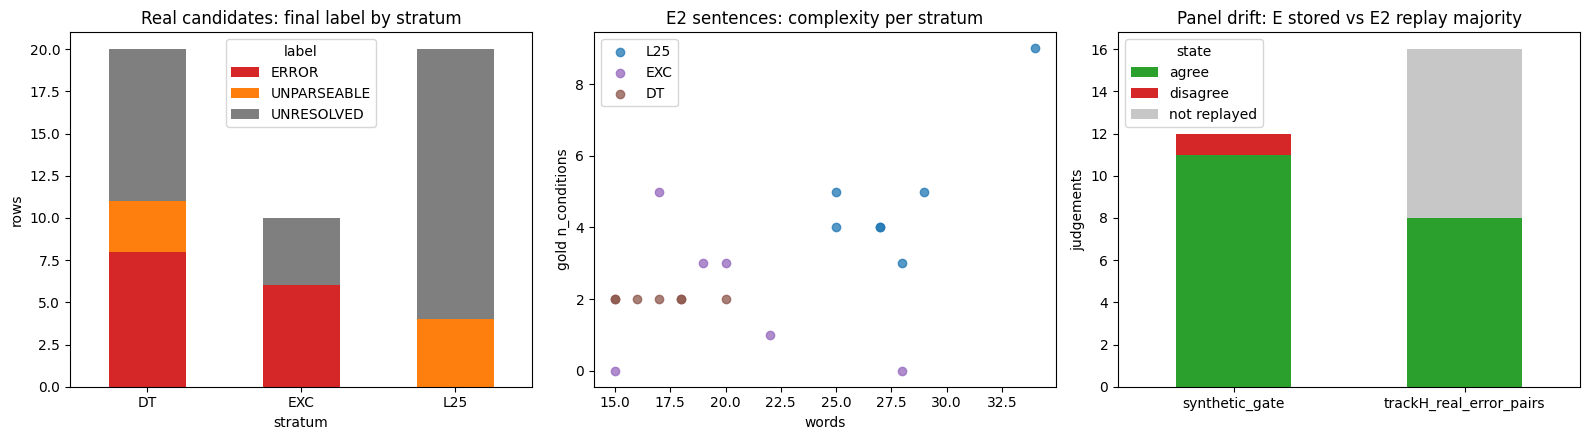

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) candidate labels per stratum
lab.plot(kind="bar", stacked=True, ax=axes[0], color={"ERROR": "#d62728", "UNRESOLVED": "#7f7f7f", "UNPARSEABLE": "#ff7f0e", "CORRECT": "#2ca02c"})
axes[0].set_title("Real candidates: final label by stratum")
axes[0].set_xlabel("stratum"); axes[0].set_ylabel("rows"); axes[0].tick_params(axis="x", rotation=0)

# (b) sentence length vs number of conditions, per stratum
for s, c in zip(["L25", "EXC", "DT"], ["#1f77b4", "#9467bd", "#8c564b"]):
    d = sent_df[sent_df["stratum"] == s]
    axes[1].scatter(d["words"], d["n_conditions"], label=s, color=c, alpha=0.75)
axes[1].set_title("E2 sentences: complexity per stratum")
axes[1].set_xlabel("words"); axes[1].set_ylabel("gold n_conditions"); axes[1].legend()

# (c) panel drift agreement
cnt = drift_df.assign(state=drift_df.apply(lambda r: "not replayed" if not r["replayed"] else ("agree" if r["agree"] else "disagree"), axis=1)) \
              .groupby(["subset", "state"]).size().unstack(fill_value=0)
cnt.plot(kind="bar", stacked=True, ax=axes[2], color={"agree": "#2ca02c", "disagree": "#d62728", "not replayed": "#c7c7c7"})
axes[2].set_title("Panel drift: E stored vs E2 replay majority")
axes[2].set_xlabel(""); axes[2].set_ylabel("judgements"); axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()